<a href="https://colab.research.google.com/github/adedamolamabeli-cyber/AI-Powered-Assessment-System-Cohort-4.0/blob/main/Adedamola_Mabel_Ibironke_Kidney_Disease_Model_Dataverse_Cohort_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

In [2]:
!pip install imbalanced-learn

In [3]:
df = pd.read_csv("kidney_disease_dataset.csv")
df.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


In [4]:
df.shape

(20538, 43)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 43 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       20538 non-null  int64  
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  object 
 6   Pus cells in urine                           20538 non-null  object 
 7   Pus cell clumps in urine                     20538 non-null  object 
 8   Bacteria in urine                            20538 non-null  object 
 9   Random blood glucose level (mg/dl)           20538 non-null  int64  
 10

In [6]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = LabelEncoder().fit_transform(df[col])

In [7]:
df.isnull().sum()

,0
Age of the patient,0
Blood pressure (mm/Hg),0
Specific gravity of urine,0
Albumin in urine,0
Sugar in urine,0
Red blood cells in urine,0
Pus cells in urine,0
Pus cell clumps in urine,0
Bacteria in urine,0
Random blood glucose level (mg/dl),0


In [8]:
df["Target"].value_counts()

,count
Target,
3,16432
1,2054
2,821
0,821
4,410


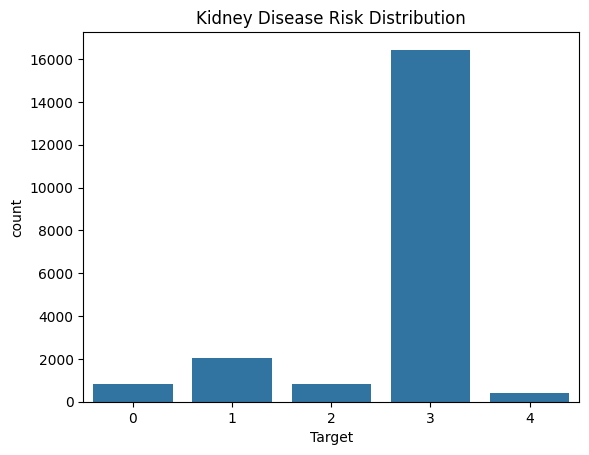

In [9]:
sns.countplot(x=df["Target"])
plt.title("Kidney Disease Risk Distribution")
plt.show()

In [10]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [11]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [15]:
model = RandomForestClassifier( n_estimators=200, random_state=42)

model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=200, random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7597370983446933


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.04      0.01      0.01       168
           1       0.14      0.07      0.09       416
           2       0.08      0.01      0.02       155
           3       0.80      0.94      0.86      3296
           4       0.00      0.00      0.00        73

    accuracy                           0.76      4108
   macro avg       0.21      0.21      0.20      4108
weighted avg       0.66      0.76      0.70      4108



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
importance = model.feature_importances_

feature_names = X.columns

feat_importance = pd.Series(importance, index=feature_names)

feat_importance = feat_importance.sort_values(ascending=False)

feat_importance.head(10)

,0
White blood cell count (cells/cumm),0.059148
Urine output (ml/day),0.050119
Random blood glucose level (mg/dl),0.033102
Blood urea (mg/dl),0.031121
Serum albumin level,0.030728
Sodium level (mEq/L),0.030606
Serum phosphate level,0.030346
Parathyroid hormone (PTH) level,0.030220
Specific gravity of urine,0.030218
Potassium level (mEq/L),0.029936


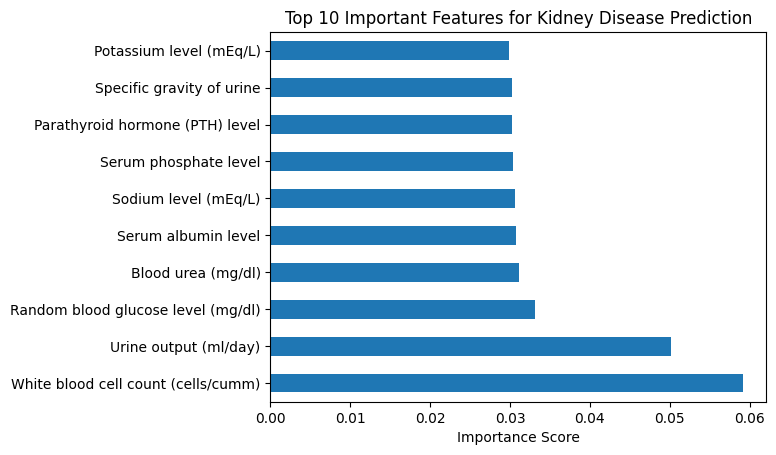

In [20]:
feat_importance.head(10).plot(kind="barh")

plt.title("Top 10 Important Features for Kidney Disease Prediction")

plt.xlabel("Importance Score")

plt.show()

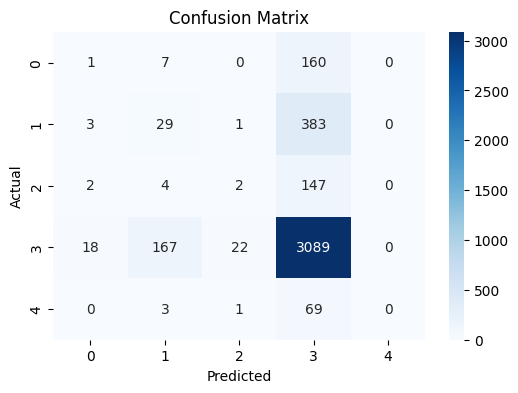

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [22]:
dt = DecisionTreeClassifier()

dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.47979552093476147


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6268257059396299
